# Vertex AI API - Data Ingestion and Exploration

In [1]:
# Standard library imports
import os
import sys
from pathlib import Path

# Data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import our custom utilities
import vertex_ai_utils as vai

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
plt.style.use('default')
sns.set_palette("husl")

In [2]:
# Define data path
DATA_PATH = 'data/Tweets.csv'

# Load the data
df = vai.load_twitter_data(DATA_PATH)

# Display first few rows
print("\nFirst 5 rows of the dataset:")
df.head()

Successfully loaded 14640 tweets from data/Tweets.csv

First 5 rows of the dataset:


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials to the experience... tacky.,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I need to take another trip!,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &...",NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing about it,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [3]:
# Display data types and basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null  object 
 13  t

In [4]:
# Print comprehensive dataset summary
vai.print_dataset_summary(df)

DATASET SUMMARY

 Basic Information:
Total Records: 14,640
Number of Columns: 15
Memory Usage: 9.87 MB

 Columns:
tweet_id                       - Type: int64      - Missing:      0 ( 0.00%)
airline_sentiment              - Type: object     - Missing:      0 ( 0.00%)
airline_sentiment_confidence   - Type: float64    - Missing:      0 ( 0.00%)
negativereason                 - Type: object     - Missing:  5,462 (37.31%)
negativereason_confidence      - Type: float64    - Missing:  4,118 (28.13%)
airline                        - Type: object     - Missing:      0 ( 0.00%)
airline_sentiment_gold         - Type: object     - Missing: 14,600 (99.73%)
name                           - Type: object     - Missing:      0 ( 0.00%)
negativereason_gold            - Type: object     - Missing: 14,608 (99.78%)
retweet_count                  - Type: int64      - Missing:      0 ( 0.00%)
text                           - Type: object     - Missing:      0 ( 0.00%)
tweet_coord                    - Type: 

In [5]:
# Get dataset information as a dictionary
dataset_info = vai.get_dataset_info(df)

print("\nSentiment Distribution:")
for sentiment, count in dataset_info['sentiment_distribution'].items():
    pct = dataset_info['sentiment_percentages'][sentiment]
    print(f"  {sentiment:10s}: {count:6,} ({pct:5.2f}%)")


Sentiment Distribution:
  negative  :  9,178 (62.69%)
  neutral   :  3,099 (21.17%)
  positive  :  2,363 (16.14%)


In [6]:
# Analyze text statistics
vai.print_text_statistics(df)

TEXT STATISTICS

 Text Length Statistics:
Mean: 103.82 characters
Median: 114.00 characters
Min: 12 characters
Max: 186 characters
Std Dev: 36.28 characters

 Word Count Statistics:
Mean: 17.65 words
Median: 19.00 words
Min: 2 words
Max: 36 words

 Content Features:
Tweets with URLs: 1,173 (8.01%)
Tweets with Mentions: 14,640 (100.00%)
Tweets with Hashtags: 2,489 (17.00%)
Average Exclamation Marks: 0.36
Average Question Marks: 0.32

Text Length by Sentiment:
neutral   :  87.36 chars, 14.41 words
positive  :  86.08 chars, 14.01 words
negative  : 113.95 chars, 19.69 words


In [7]:
# Sample tweets by sentiment
vai.sample_tweets_by_sentiment(df, n_samples=5)

SAMPLE TWEETS BY SENTIMENT
POSITIVE TWEETS

1. Airline: Southwest | Confidence: 1.0
   Tweet: @SouthwestAir thanks for your excellent response time and assistance! All set :)

2. Airline: Delta | Confidence: 1.0
   Tweet: @JetBlue thanks. I appreciate your prompt response.

3. Airline: Delta | Confidence: 1.0
   Tweet: @JetBlue yes, with about 20 minutes to spare.  FYI - your employees are amazing.  Keep up the good work!

4. Airline: US Airways | Confidence: 1.0
   Tweet: @USAirways YOU ARE THE BEST!!! FOLLOW ME PLEASE;)🙏🙏🙏✌️✌️✌️🙏🙏🙏

5. Airline: Delta | Confidence: 1.0
   Tweet: @JetBlue beautiful ride. Thanks again:)
NEUTRAL TWEETS

1. Airline: United | Confidence: 0.3512
   Tweet: @united we finally just arrive to Bogota, good but long flight!!

2. Airline: American | Confidence: 0.6452
   Tweet: @AmericanAir got a callback at 1 am, took care of it. thanks.

3. Airline: Delta | Confidence: 1.0
   Tweet: @JetBlue is there wifi on he plain

4. Airline: Delta | Confidence: 0.6639
   Tw

Figure saved to data/processed/figures/sentiment_distribution.png


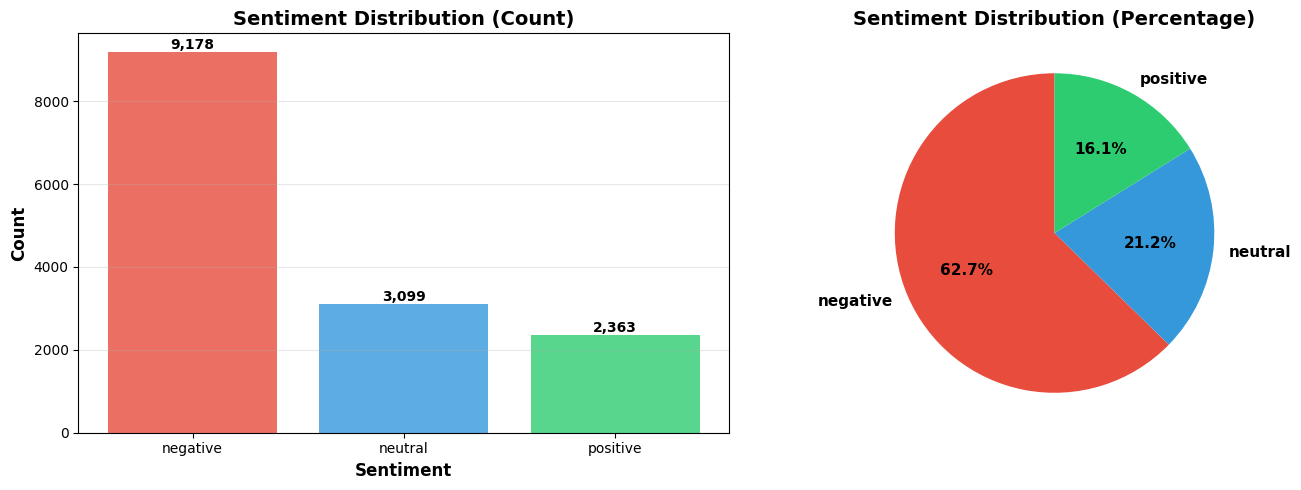

In [8]:
# Visualize sentiment distribution
vai.visualize_sentiment_distribution(df, save_path='data/processed/figures/sentiment_distribution.png')

Figure saved to data/processed/figures/airline_sentiment.png


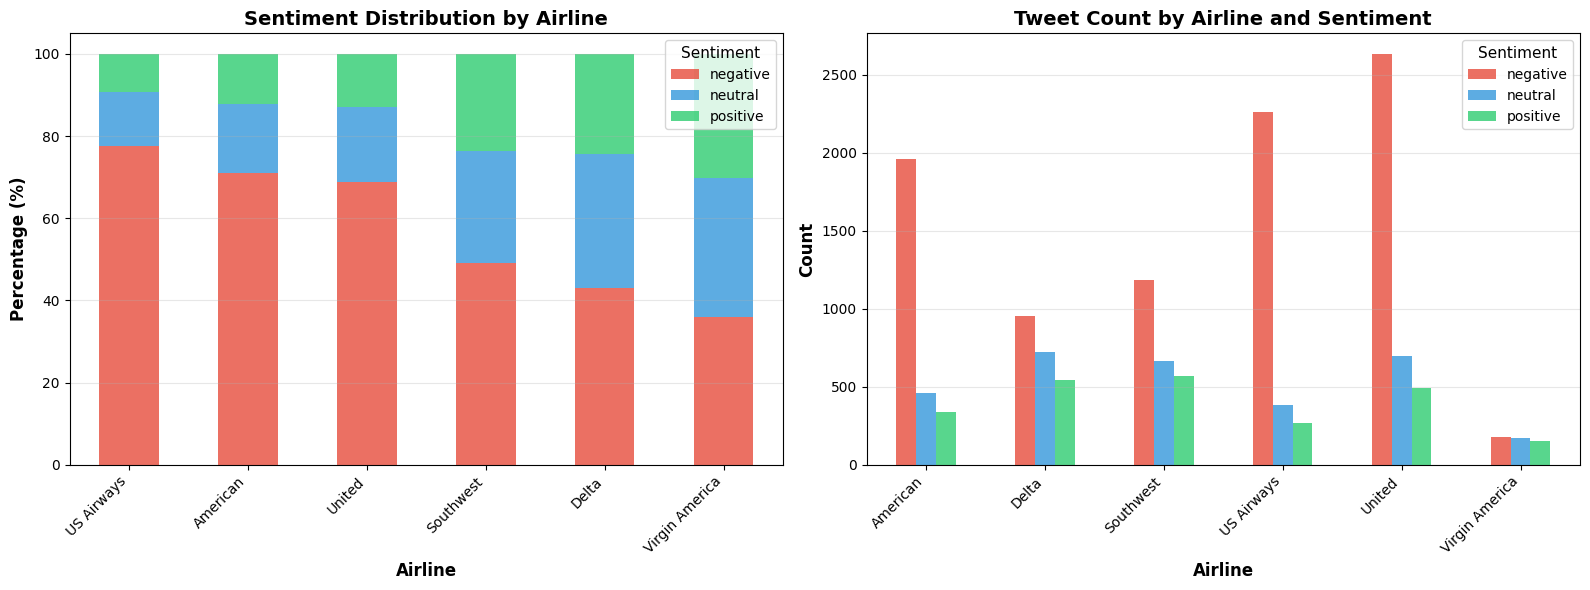

In [9]:
# Visualize sentiment by airline
vai.visualize_airline_sentiment(df, save_path='data/processed/figures/airline_sentiment.png')

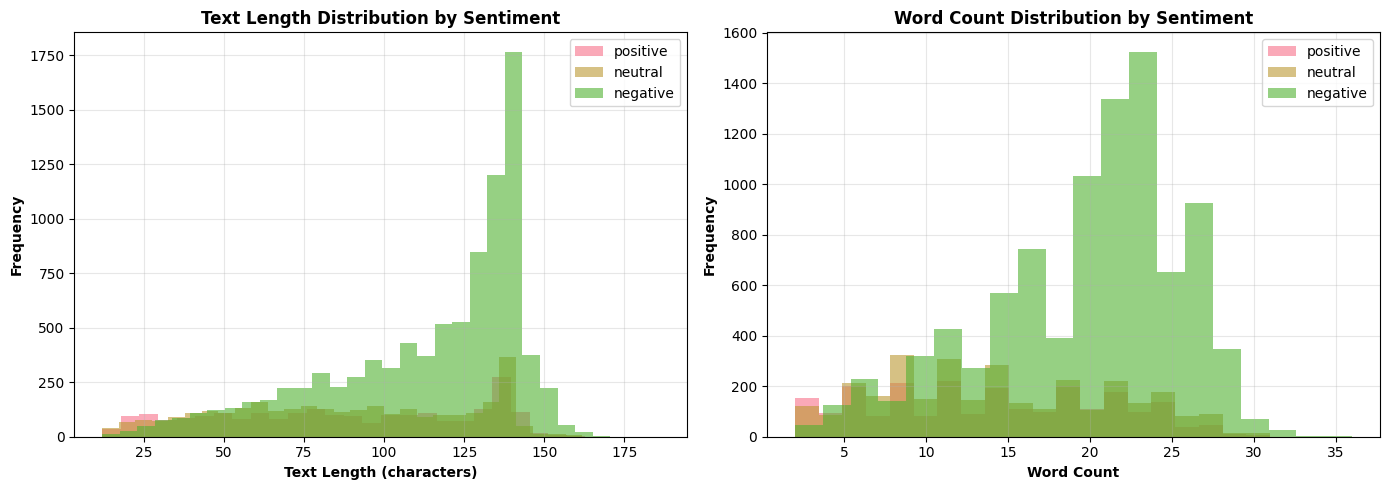

In [10]:
# Additional visualizations - Text length distribution by sentiment
stats_df = vai.analyze_text_statistics(df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Text length distribution
for sentiment in ['positive', 'neutral', 'negative']:
    sentiment_data = stats_df[stats_df['airline_sentiment'] == sentiment]['text_length']
    axes[0].hist(sentiment_data, alpha=0.6, label=sentiment, bins=30)

axes[0].set_xlabel('Text Length (characters)', fontweight='bold')
axes[0].set_ylabel('Frequency', fontweight='bold')
axes[0].set_title('Text Length Distribution by Sentiment', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Word count distribution
for sentiment in ['positive', 'neutral', 'negative']:
    sentiment_data = stats_df[stats_df['airline_sentiment'] == sentiment]['word_count']
    axes[1].hist(sentiment_data, alpha=0.6, label=sentiment, bins=20)

axes[1].set_xlabel('Word Count', fontweight='bold')
axes[1].set_ylabel('Frequency', fontweight='bold')
axes[1].set_title('Word Count Distribution by Sentiment', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# Split data into train/val/test sets
train_df, val_df, test_df = vai.split_train_val_test(
    df,
    train_ratio=0.7,
    val_ratio=0.15,
    test_ratio=0.15,
    stratify_column='airline_sentiment',
    random_state=42
)

Training set:   10,248 records (70.0%)
Validation set:  2,196 records (15.0%)
Test set:        2,196 records (15.0%)

  Sentiment distribution verification:
   Train: positive: 16.15%  neutral: 21.17%  negative: 62.69%     Val  : positive: 16.12%  neutral: 21.17%  negative: 62.70%     Test : positive: 16.12%  neutral: 21.17%  negative: 62.70%  

In [12]:
# Verify the splits
print("\nDataset Sizes:")
print(f"Training set:   {len(train_df):6,} samples")
print(f"Validation set: {len(val_df):6,} samples")
print(f"Test set:       {len(test_df):6,} samples")
print(f"Total:          {len(train_df) + len(val_df) + len(test_df):6,} samples")


Dataset Sizes:
Training set:   10,248 samples
Validation set:  2,196 samples
Test set:        2,196 samples
Total:          14,640 samples


In [13]:
# Prepare training data in JSONL format
train_jsonl_path = vai.prepare_data_for_vertex_ai(
    train_df,
    text_column='text',
    label_column='airline_sentiment',
    output_path='data/processed/train_data.jsonl'
)

Saved to: data/processed/train_data.jsonl


In [14]:
# Prepare validation data in JSONL format
val_jsonl_path = vai.prepare_data_for_vertex_ai(
    val_df,
    text_column='text',
    label_column='airline_sentiment',
    output_path='data/processed/val_data.jsonl'
)

Saved to: data/processed/val_data.jsonl


In [15]:
# Prepare test data in JSONL format
test_jsonl_path = vai.prepare_data_for_vertex_ai(
    test_df,
    text_column='text',
    label_column='airline_sentiment',
    output_path='data/processed/test_data.jsonl'
)

Saved to: data/processed/test_data.jsonl


In [16]:
# Display sample JSONL records
print("Sample JSONL records from training data:")
print("=" * 80)

with open(train_jsonl_path, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i < 3:  # Show first 3 records
            import json
            record = json.loads(line)
            print(f"\nRecord {i+1}:")
            print(f"  Category: {record['category']}")
            print(f"  Text: {record['text_content'][:100]}...")
        else:
            break

Sample JSONL records from training data:

Record 1:
  Category: negative
  Text: @AmericanAir since you don't care about what happens to your passengers on your planes we will now b...

Record 2:
  Category: negative
  Text: @united yea they been booked on 10 next avalible flights since sat 7am. And when time comes no plane...

Record 3:
  Category: negative
  Text: @JetBlue the departure time keeps getting Late Flightr.  I'll be lucky if I'm home by 3am...


In [17]:
# Save split datasets as CSV for reference
train_df.to_csv('data/processed/train_data.csv', index=False)
val_df.to_csv('data/processed/val_data.csv', index=False)
test_df.to_csv('data/processed/test_data.csv', index=False)

print("✓ All datasets saved successfully!")
print("\nFiles created:")
print("  • data/processed/train_data.csv")
print("  • data/processed/train_data.jsonl")
print("  • data/processed/val_data.csv")
print("  • data/processed/val_data.jsonl")
print("  • data/processed/test_data.csv")
print("  • data/processed/test_data.jsonl")

✓ All datasets saved successfully!

Files created:
  • data/processed/train_data.csv
  • data/processed/train_data.jsonl
  • data/processed/val_data.csv
  • data/processed/val_data.jsonl
  • data/processed/test_data.csv
  • data/processed/test_data.jsonl
